In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [45]:
df = pd.read_csv("webp_compression_report.csv")
df.head()

,Relative Path,Original Size,Scale,Has Alpha,File Type,ICC Profile,Lossless Size,Lossless No Alpha Size,lossy_q75_m0_a100,lossy_q75_m0_a80,...,lossy_q50_m6_no_alpha,lossy_q25_m0_a100,lossy_q25_m0_a80,lossy_q25_m0_no_alpha,lossy_q25_m4_a100,lossy_q25_m4_a80,lossy_q25_m4_no_alpha,lossy_q25_m6_a100,lossy_q25_m6_a80,lossy_q25_m6_no_alpha
0,images/bg-disallowed.png,593,17x17,True,PNG,Unknown,740,656.0,788.0,788.0,...,680,788.0,788.0,682,782.0,782.0,680,738.0,782.0,680
1,images/news/20150524-ra-map-chooser.png,34180,600x300,False,PNG,NaN,23036,NaN,NaN,NaN,...,17896,NaN,NaN,18202,NaN,NaN,13562,NaN,NaN,12868
2,images/about/tiberian-sun.jpg,94759,624x351,False,JPG,NaN,363356,NaN,NaN,NaN,...,38384,NaN,NaN,30100,NaN,NaN,25560,NaN,NaN,23208
3,images/news/20130514-ra-shellmap.png,402317,620x349,False,PNG,NaN,354958,NaN,NaN,NaN,...,17958,NaN,NaN,15230,NaN,NaN,11768,NaN,NaN,10710
4,images/about/fractured-realms.jpg,73445,624x351,False,JPG,NaN,287752,NaN,NaN,NaN,...,24870,NaN,NaN,20416,NaN,NaN,16932,NaN,NaN,15470


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Relative Path           520 non-null    object 
 1   Original Size           520 non-null    int64  
 2   Scale                   520 non-null    object 
 3   Has Alpha               520 non-null    bool   
 4   File Type               520 non-null    object 
 5   ICC Profile             40 non-null     object 
 6   Lossless Size           520 non-null    int64  
 7   Lossless No Alpha Size  276 non-null    float64
 8   lossy_q75_m0_a100       276 non-null    float64
 9   lossy_q75_m0_a80        276 non-null    float64
 10  lossy_q75_m0_no_alpha   520 non-null    int64  
 11  lossy_q75_m4_a100       276 non-null    float64
 12  lossy_q75_m4_a80        276 non-null    float64
 13  lossy_q75_m4_no_alpha   520 non-null    int64  
 14  lossy_q75_m6_a100       276 non-null    fl

In [6]:
df["File Type"].value_counts()

File Type
PNG     472
GIF      26
JPG      16
WEBP      6
Name: count, dtype: int64

In [7]:
df["ICC Profile"].value_counts()

ICC Profile
Unknown    40
Name: count, dtype: int64

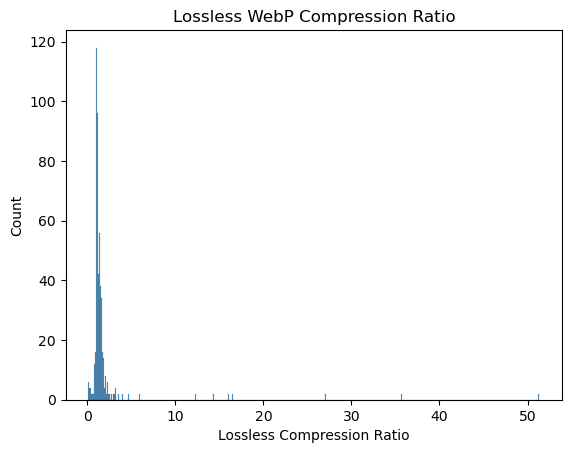

In [52]:
df["Lossless Compression Ratio"] = df["Original Size"] / df["Lossless Size"]
sns.histplot(df["Lossless Compression Ratio"])
plt.title("Lossless WebP Compression Ratio")
plt.show()

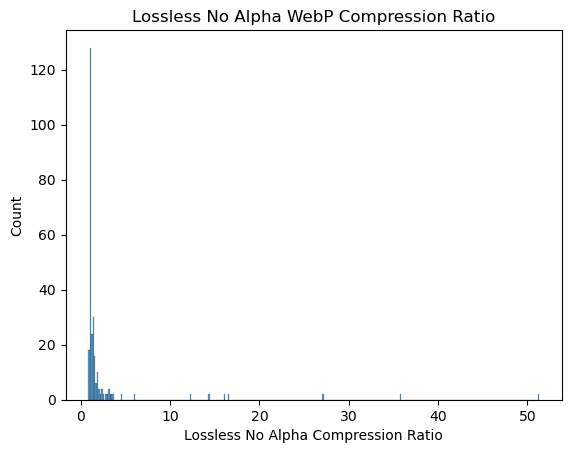

In [54]:
df["Lossless No Alpha Compression Ratio"] = df["Original Size"] / df["Lossless No Alpha Size"]
sns.histplot(df["Lossless No Alpha Compression Ratio"])
plt.title("Lossless No Alpha WebP Compression Ratio")
plt.show()


In [ ]:
import os

# Filter the dataframe to include only rows where the lossy compression ratio is greater than 1
df_wins = lossy_df[lossy_df["Lossy Compression Ratio"] > 1]
df_wins = lossy_df[lossy_df["File Type"] != "GIF"]

# Extract the unique relative paths where we got a win
win_paths = df_wins["Relative Path"].unique()

def replace_in_file(file_path, win_paths):
    with open(file_path, 'r') as file:
        content = file.read()
    for win_path in win_paths:
        content = content.replace(win_path, win_path.replace('.png', '.webp').replace('.jpg', '.webp'))
    with open(file_path, 'w') as file:
        file.write(content)

def replace_in_markdown_files(directory, win_paths):
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith('.html'):
                file_path = os.path.join(root, file)
                replace_in_file(file_path, win_paths)

# Replace in markdown files in the current directory
# replace_in_markdown_files('.', win_paths)

In [60]:
# Sort win_paths to have the worse compression first
win_paths_sorted = sorted(win_paths, key=lambda x: (x.rsplit('.', 1)[0], x.rsplit('.', 1)[1] != 'webp'))

# Replace in markdown files in the current directory
replace_in_markdown_files('.', win_paths_sorted)

win_paths_str = ' '.join(win_paths)
print(win_paths_str)

images/bg-disallowed.png images/news/20150524-ra-map-chooser.png images/about/tiberian-sun.jpg images/news/20130514-ra-shellmap.png images/about/fractured-realms.jpg images/news/20150424-cnc-server-browser.png images/news/20210321-spotlight-soon.jpg images/news/20150808-d2k-range-circles.png images/heroes/red-alert.png images/about/red-alert.png images/news/20241116-eva.webp images/news/20160403-d2k-adv-settings.png images/news/20151031-scrolling.png images/heroes/dune-2000.png images/about/command-and-conquer.png images/about/dune-2000.png images/heroes/command-and-conquer.png images/social.png images/social.jpg images/news/20160904-cnc-contentinstall.png images/news/20150118-cnc-colored-game-servers-heading.png images/news/20151031-d2k.png images/news/20170401-chrono-speed-up.png images/news/20140927-aircraft.png images/news/20200629-selection.png images/news/20160403-ra-team-colors.png images/news/20140608-ra.png images/news/20150614-web-server-browser.png images/news/20150628-edito

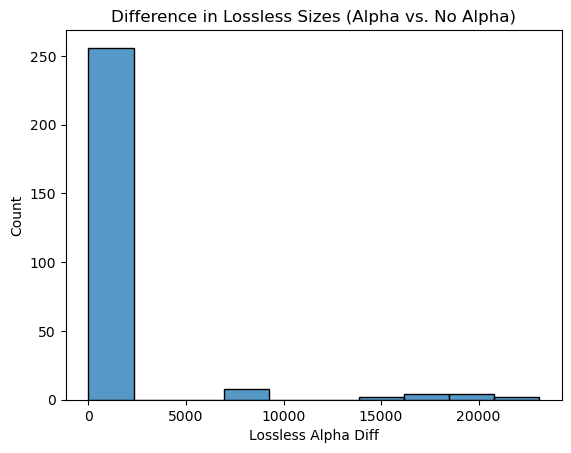

In [9]:
df["Lossless Alpha Diff"] = df["Lossless Size"] - df["Lossless No Alpha Size"]
sns.histplot(df["Lossless Alpha Diff"].dropna())
plt.title("Difference in Lossless Sizes (Alpha vs. No Alpha)")
plt.show()

In [11]:
def extract_settings(col_name):
    if col_name.startswith("lossy_"):
        parts = col_name.split("_")
        quality = int(parts[1][1:])
        method = int(parts[2][1:])
        if "a" in parts[3]:
            alpha = int(parts[3][1:])
            no_alpha = False
        else:
            alpha = None
            no_alpha = True
        return quality, method, alpha, no_alpha
    else:
        return None

lossy_cols = [col for col in df.columns if col.startswith("lossy_")]
lossy_data = []

for index, row in df.iterrows():
    for col in lossy_cols:
        settings = extract_settings(col)
        if settings:
            quality, method, alpha, no_alpha = settings
            lossy_size = row[col]
            lossy_data.append({
                "Relative Path": row["Relative Path"],
                "Original Size": row["Original Size"],
                "Quality": quality,
                "Method": method,
                "Alpha Quality": alpha,
                "No Alpha": no_alpha,
                "Lossy Size": lossy_size
            })

lossy_df = pd.DataFrame(lossy_data)

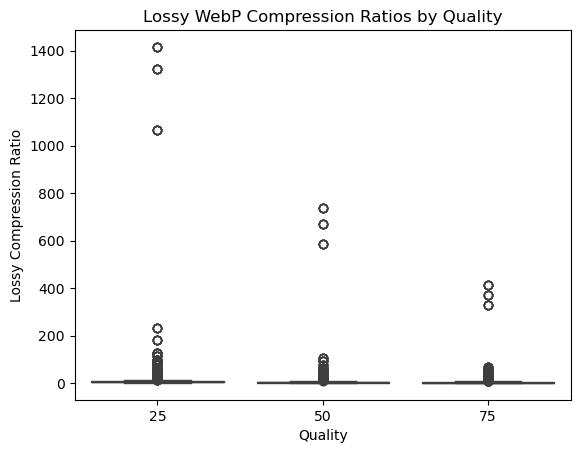

In [12]:
lossy_df["Lossy Compression Ratio"] = lossy_df["Original Size"] / lossy_df["Lossy Size"]
sns.boxplot(x="Quality", y="Lossy Compression Ratio", data=lossy_df)
plt.title("Lossy WebP Compression Ratios by Quality")
plt.show()

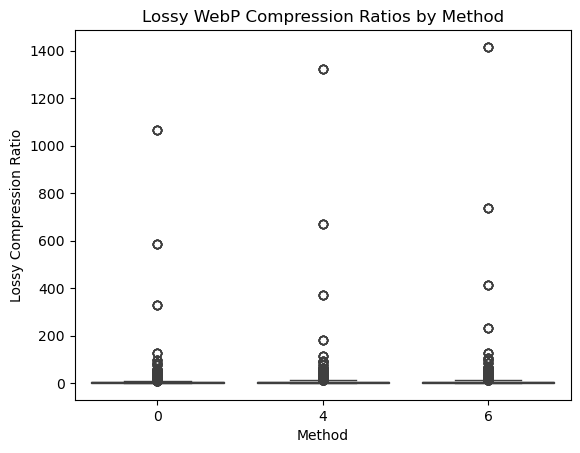

In [13]:
sns.boxplot(x="Method", y="Lossy Compression Ratio", data=lossy_df)
plt.title("Lossy WebP Compression Ratios by Method")
plt.show()

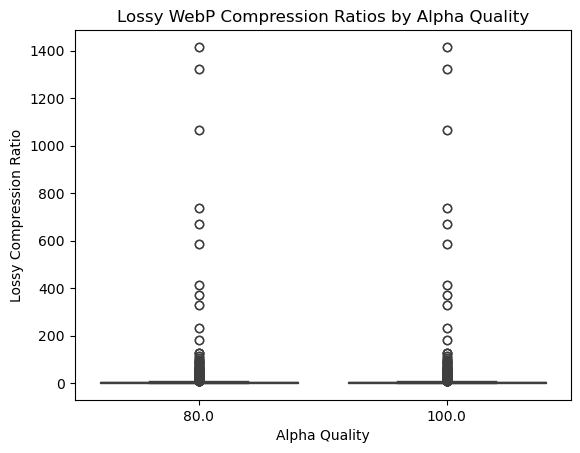

In [14]:
lossy_alpha = lossy_df.dropna(subset=['Alpha Quality'])
sns.boxplot(x="Alpha Quality", y="Lossy Compression Ratio", data=lossy_alpha)
plt.title("Lossy WebP Compression Ratios by Alpha Quality")
plt.show()

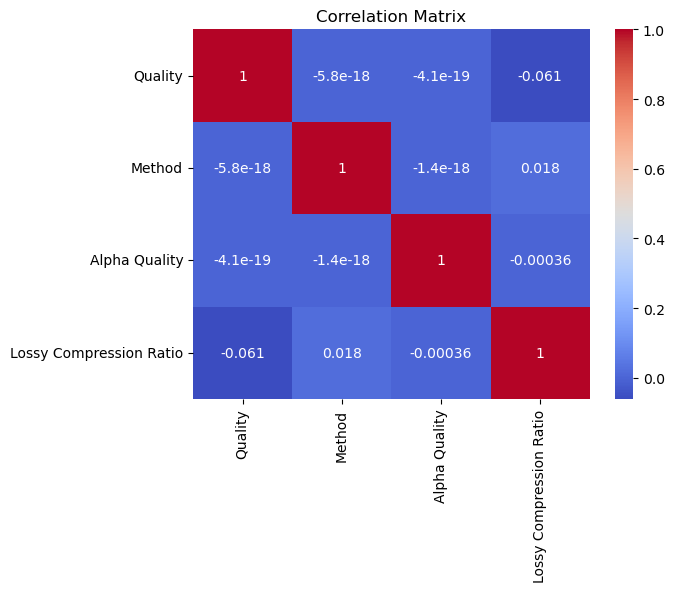

In [15]:
correlation_matrix = lossy_df[["Quality", "Method", "Alpha Quality", "Lossy Compression Ratio"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [18]:
def extract_settings(col_name):
    if col_name.startswith("lossy_"):
        parts = col_name.split("_")
        quality = int(parts[1][1:])
        method = int(parts[2][1:])
        if "a" in parts[3]:
            alpha = int(parts[3][1:])
            no_alpha = False
        else:
            alpha = None
            no_alpha = True
        return quality, method, alpha, no_alpha
    else:
        return None

for file_type in df["File Type"].unique():
    print(f"\nAnalyzing {file_type} files:")
    
    # Filter the dataframe
    df_filtered = df[df["File Type"] == file_type].copy()

    # Lossless analysis
    df_filtered["Lossless Compression Ratio"] = df_filtered["Original Size"] / df_filtered["Lossless Size"]
    print("Lossless WebP Compression Ratio:")
    print(df_filtered["Lossless Compression Ratio"].describe())

    # Lossless alpha difference
    df_filtered["Lossless Alpha Diff"] = df_filtered["Lossless Size"] - df_filtered["Lossless No Alpha Size"]
    print("Difference in Lossless Sizes (Alpha vs No Alpha):")
    print(df_filtered["Lossless Alpha Diff"].describe())

    # Lossy analysis
    lossy_cols = [col for col in df_filtered.columns if col.startswith("lossy_")]
    lossy_data = []

    for index, row in df_filtered.iterrows():
        for col in lossy_cols:
            settings = extract_settings(col)
            if settings:
                quality, method, alpha, no_alpha = settings
                lossy_size = row[col]
                lossy_data.append({
                    "Relative Path": row["Relative Path"],
                    "Original Size": row["Original Size"],
                    "Quality": quality,
                    "Method": method,
                    "Alpha Quality": alpha,
                    "No Alpha": no_alpha,
                    "Lossy Size": lossy_size
                })

    lossy_df = pd.DataFrame(lossy_data)

    # Lossy compression ratios
    lossy_df["Lossy Compression Ratio"] = lossy_df["Original Size"] / lossy_df["Lossy Size"]
    print("Lossy WebP Compression Ratios by Quality:")
    print(lossy_df.groupby("Quality")["Lossy Compression Ratio"].describe())

    print("Lossy WebP Compression Ratios by Method:")
    print(lossy_df.groupby("Method")["Lossy Compression Ratio"].describe())

    # Alpha quality impact
    lossy_alpha = lossy_df.dropna(subset=['Alpha Quality'])
    print("Lossy WebP Compression Ratios by Alpha Quality:")
    print(lossy_alpha.groupby("Alpha Quality")["Lossy Compression Ratio"].describe())

    # Correlation analysis
    correlation_matrix = lossy_df[["Quality", "Method", "Alpha Quality", "Lossy Compression Ratio"]].corr()
    print("Correlation Matrix:")
    print(correlation_matrix)

    # ICC Profile analysis
    icc_counts = df_filtered["ICC Profile"].value_counts()
    print("ICC Profile Counts:")
    print(icc_counts)


Analyzing PNG files:
Lossless WebP Compression Ratio:
count    472.000000
mean       1.342314
std        0.455082
min        0.429245
25%        1.091955
50%        1.201432
75%        1.479363
max        4.641115
Name: Lossless Compression Ratio, dtype: float64
Difference in Lossless Sizes (Alpha vs No Alpha):
count      250.000000
mean      1219.392000
std       4195.195249
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      23114.000000
Name: Lossless Alpha Diff, dtype: float64
Lossy WebP Compression Ratios by Quality:
          count      mean       std       min       25%       50%       75%  \
Quality                                                                       
25       2916.0  6.056192  7.580587  0.507268  2.363963  3.411059  6.379434   
50       2916.0  4.063988  5.007294  0.443552  1.599149  2.159438  4.509722   
75       2916.0  3.100887  3.741993  0.343120  1.203338  1.645043  3.567909   

               max  
Quality  

In [31]:
# Lossless Analysis
df["Lossless Compression Ratio"] = df["Original Size"] / df["Lossless Size"]
df["Lossless Alpha Diff"] = df["Lossless Size"] - df["Lossless No Alpha Size"]

Outliers:
                                         Relative Path  Original Size  \
2                        images/about/tiberian-sun.jpg          94759   
4                    images/about/fractured-realms.jpg          73445   
18                                   images/social.jpg          98618   
36                               images/bg-texture.jpg         148940   
59                   images/news/20170421-td-hidpi.gif          82096   
66            images/news/20190209-opportunityfire.gif         677045   
69         images/news/20190606-directional-powers.gif         546926   
84                 images/news/20190606-td-sidebar.gif         545519   
97                    images/news/20140204-players.png          15940   
127                     images/news/2017-christmas.gif         186561   
130                images/news/20200303-rallypoint.gif          73176   
131             images/news/20130514-bridge-repair.png          64812   
156                   images/news/2014020

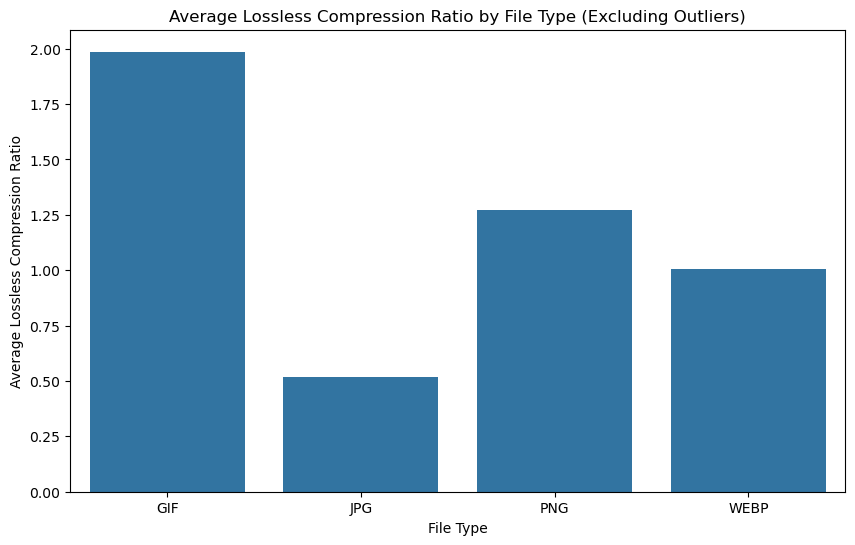

In [34]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df["Lossless Compression Ratio"].quantile(0.25)
Q3 = df["Lossless Compression Ratio"].quantile(0.75)

# Calculate IQR (Interquartile Range)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
outliers = df[(df["Lossless Compression Ratio"] < lower_bound) | (df["Lossless Compression Ratio"] > upper_bound)]
df_no_outliers = df[(df["Lossless Compression Ratio"] >= lower_bound) & (df["Lossless Compression Ratio"] <= upper_bound)]

# Print the list of outliers
print("Outliers:")
print(outliers)

# Group by file type and calculate the mean lossless compression ratio without outliers
lossless_gains_no_outliers = df_no_outliers.groupby("File Type")["Lossless Compression Ratio"].mean().reset_index()

# Plot the lossless gains without outliers
plt.figure(figsize=(10, 6))
sns.barplot(x="File Type", y="Lossless Compression Ratio", data=lossless_gains_no_outliers)
plt.title("Average Lossless Compression Ratio by File Type (Excluding Outliers)")
plt.xlabel("File Type")
plt.ylabel("Average Lossless Compression Ratio")
plt.show()

In [ ]:
def extract_settings(col_name):
    if col_name.startswith("lossy_"):
        parts = col_name.split("_")
        quality = int(parts[1][1:])
        method = int(parts[2][1:])
        if "a" in parts[3]:
            alpha = int(parts[3][1:])
            no_alpha = False
        else:
            alpha = None
            no_alpha = True
        return quality, method, alpha, no_alpha
    else:
        return None

# Lossy Analysis
lossy_cols = [col for col in df.columns if col.startswith("lossy_")]
lossy_data = []

for index, row in df.iterrows():
    for col in lossy_cols:
        settings = extract_settings(col)
        if settings:
            quality, method, alpha, no_alpha = settings
            lossy_size = row[col]
            lossy_data.append({
                "File Type": row["File Type"],
                "Relative Path": row["Relative Path"],
                "Original Size": row["Original Size"],
                "Quality": quality,
                "Method": method,
                "Alpha Quality": alpha,
                "No Alpha": no_alpha,
                "Lossy Size": lossy_size
            })

lossy_df = pd.DataFrame(lossy_data)
lossy_df["Lossy Compression Ratio"] = lossy_df["Original Size"] / lossy_df["Lossy Size"]

In [30]:
# Filter the dataframe to include only rows where the lossy size is greater than the original size
df_losses = lossy_df[lossy_df["Lossy Size"] > lossy_df["Original Size"]].copy()

# Ensure 'Relative Path' column exists
if 'Relative Path' in df_losses.columns:
    # Count the number of occurrences where the file sizes increased
    loss_count = df_losses.shape[0]
    print(f"Number of files where the lossy size increased: {loss_count}")

    # List the filenames where the file sizes increased
    loss_filenames = df_losses["Relative Path"].unique()
    print("Filenames where the lossy size increased:")
    for filename in loss_filenames:
        print(filename)

Number of files where the lossy size increased: 804
Filenames where the lossy size increased:
images/bg-disallowed.png
images/social.jpg
images/news/20160904-cnc-contentinstall.png
images/news/20150628-editor.png
images/news/20151031-modders.png
images/news/20161001-ra-lobby-mission-briefing.png
images/news/20130915-lobby.png
images/news/20170722-ra-commandbar.png
images/news/20140405-ra.png
images/news/20190106-editor-2x.png
images/news/20140722-musicdownload.png
images/news/20151031-gamespeed.png
images/news/20151031-installer.png
images/news/20180610-download.png
images/news/20131102-haos-ridges-cnc.png
images/news/20150329-ra-randomcountries-dropdown.png
images/news/20180729-profiles.png
images/news/20170304-hidpi.png
images/news/20140204-players.png
images/news/20150614-cnc-missions.png
images/news/20180102-serverplayers.png
images/news/20160403-cnc-nod-colors.png
images/news/20141020-replays.png
images/news/20180610-tibsun.png
images/news/20140207-players.png
images/news/20160821


Analysis for PNG files:


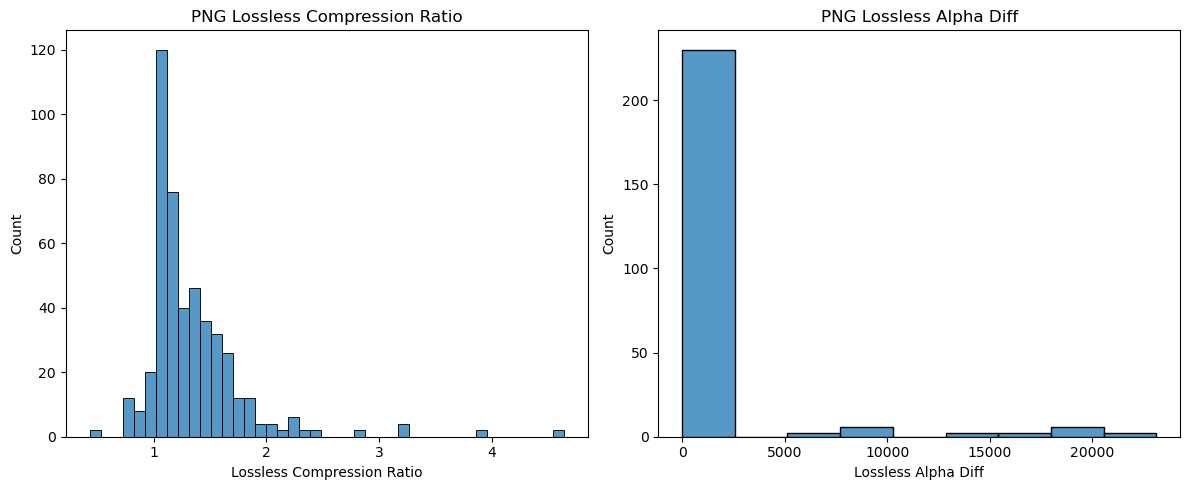

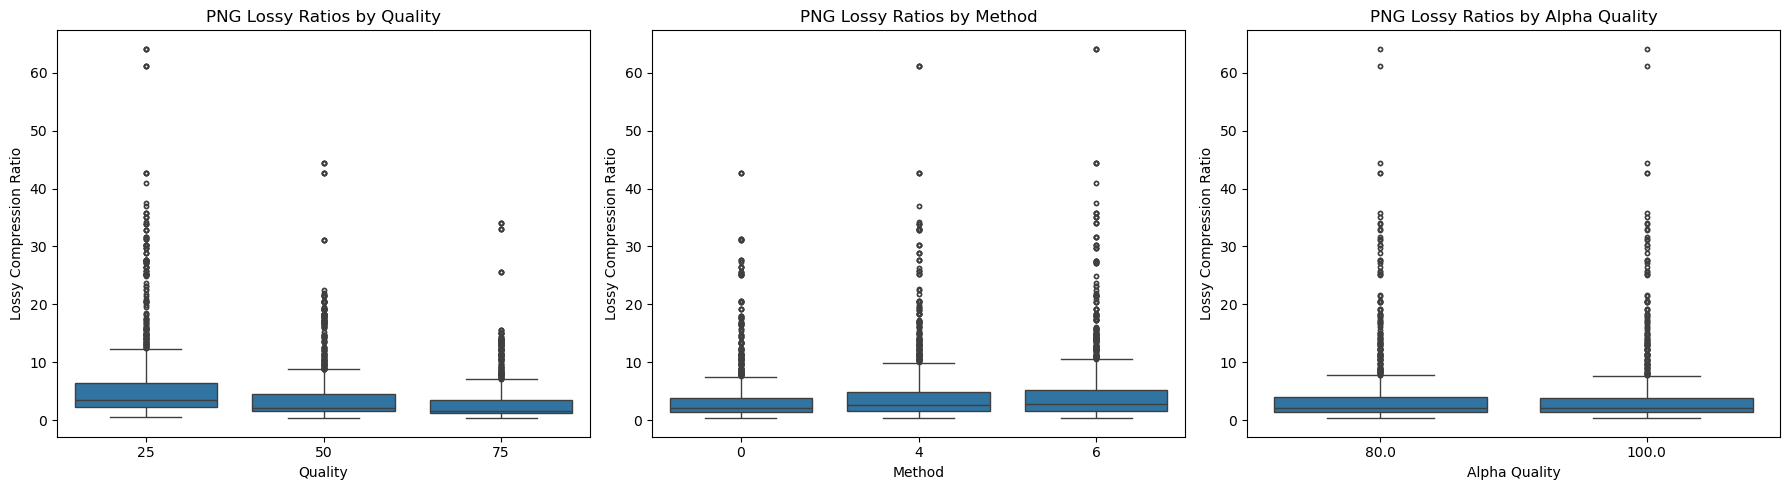

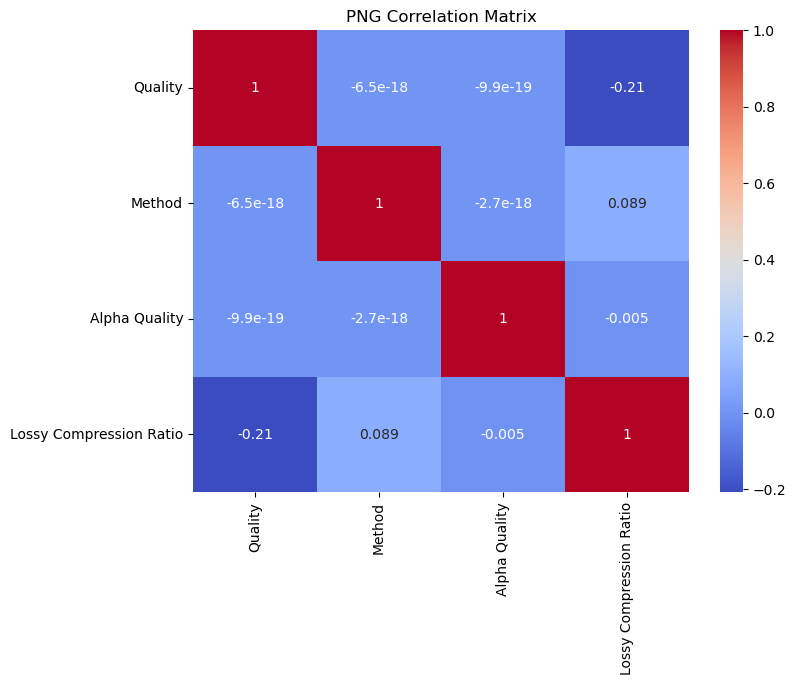

PNG ICC Profile Counts:
ICC Profile
Unknown    30
Name: count, dtype: int64

Analysis for JPG files:


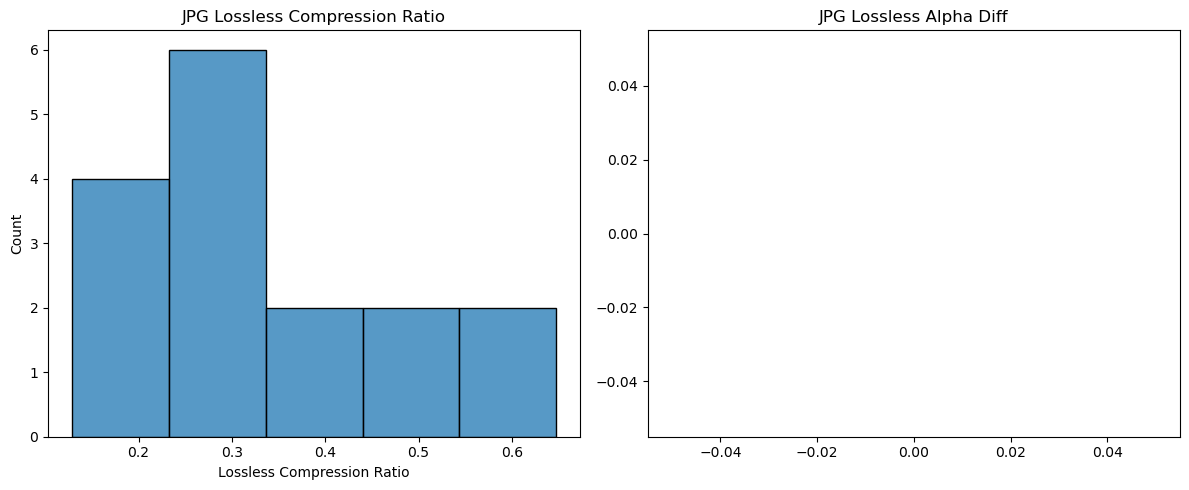

ValueError: List of boxplot statistics and `positions` values must have same the length

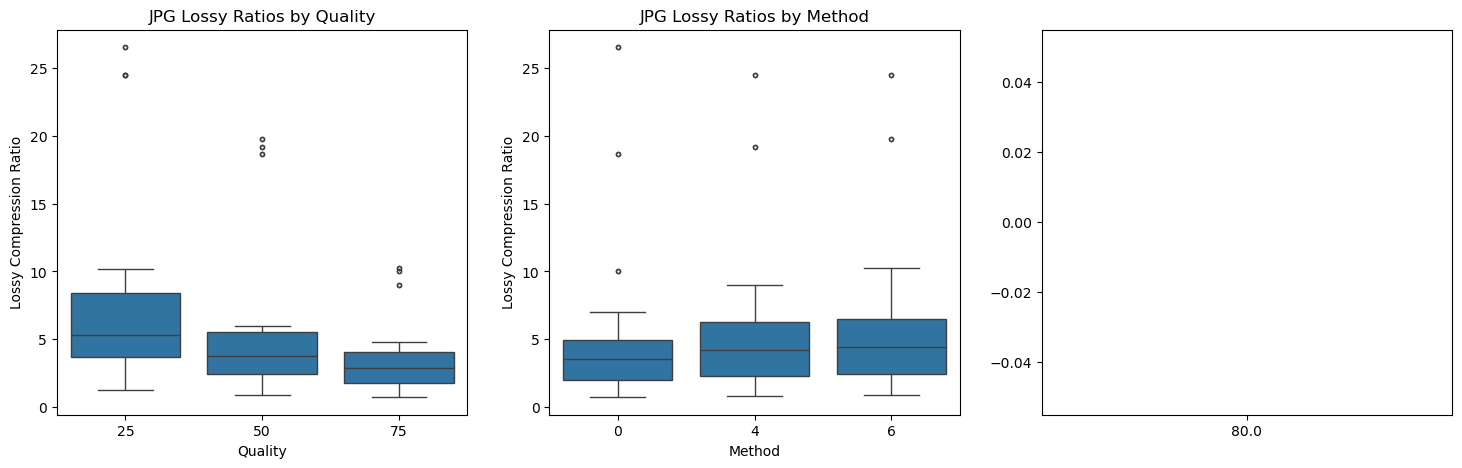

In [ ]:
# Analysis by File Type
for file_type in df["File Type"].unique():
    df_type = df[df["File Type"] == file_type]
    lossy_df_type = lossy_df[lossy_df["File Type"] == file_type]

    print(f"\nAnalysis for {file_type} files:")

    # Lossless Graphs
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df_type["Lossless Compression Ratio"].dropna())
    plt.title(f"{file_type} Lossless Compression Ratio")

    plt.subplot(1, 2, 2)
    sns.histplot(df_type["Lossless Alpha Diff"].dropna())
    plt.title(f"{file_type} Lossless Alpha Diff")
    plt.tight_layout()
    plt.show()

    # Lossy Graphs
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    sns.boxplot(x="Quality", y="Lossy Compression Ratio", data=lossy_df_type, fliersize=3) #added fliersize
    plt.title(f"{file_type} Lossy Ratios by Quality")

    plt.subplot(1, 3, 2)
    sns.boxplot(x="Method", y="Lossy Compression Ratio", data=lossy_df_type, fliersize=3) #added fliersize
    plt.title(f"{file_type} Lossy Ratios by Method")

    plt.subplot(1, 3, 3)
    lossy_alpha_type = lossy_df_type.dropna(subset=['Alpha Quality'])
    if not lossy_alpha_type.empty: #added alpha check.
        sns.boxplot(x="Alpha Quality", y="Lossy Compression Ratio", data=lossy_alpha_type, fliersize=3) #added fliersize
        plt.title(f"{file_type} Lossy Ratios by Alpha Quality")
    else:
        plt.text(0.5, 0.5, "No Alpha Data", horizontalalignment='center', verticalalignment='center', fontsize=12) #added text if no alpha data.
    plt.tight_layout()
    plt.show()

    # Correlation Matrix
    plt.figure(figsize=(8, 6))
    corr_matrix = lossy_df_type[["Quality", "Method", "Alpha Quality", "Lossy Compression Ratio"]].corr()
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
    plt.title(f"{file_type} Correlation Matrix")
    plt.show()

    # ICC Profile Counts
    print(f"{file_type} ICC Profile Counts:")
    print(df_type["ICC Profile"].value_counts())


GIF Specific Analysis:

Lossless WebP Compression Ratios for GIFs:
                                         Relative Path  \
31                images/news/20170923-assaultmove.gif   
59                   images/news/20170421-td-hidpi.gif   
66            images/news/20190209-opportunityfire.gif   
69         images/news/20190606-directional-powers.gif   
84                 images/news/20190606-td-sidebar.gif   
127                     images/news/2017-christmas.gif   
130                images/news/20200303-rallypoint.gif   
162                images/news/20190106-dog-attack.gif   
185                        images/news/20151031-td.gif   
192              images/news/20170401-french-bonus.gif   
204           images/news/20150628-carryall-repair.gif   
218                      images/news/20191021-ragl.gif   
241              images/news/20190606-map-previews.gif   
282         _site/images/news/20170923-assaultmove.gif   
321            _site/images/news/20170421-td-hidpi.gif   
324 

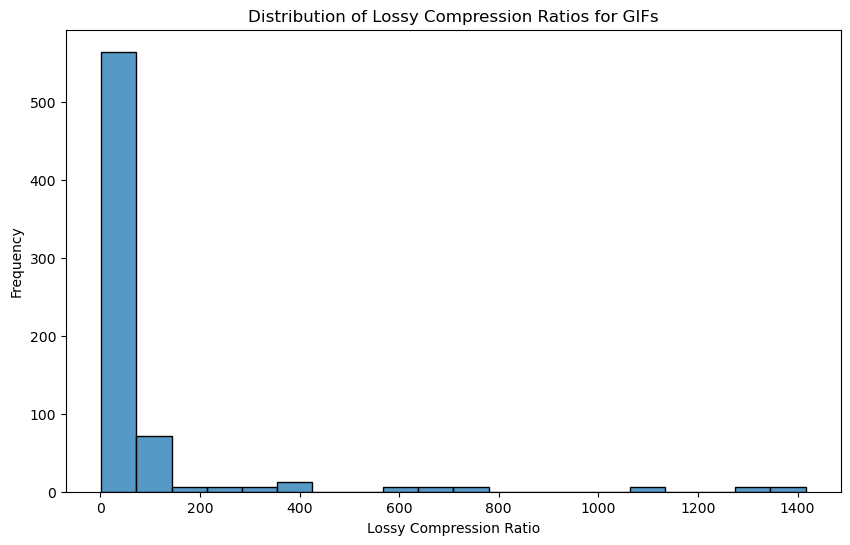

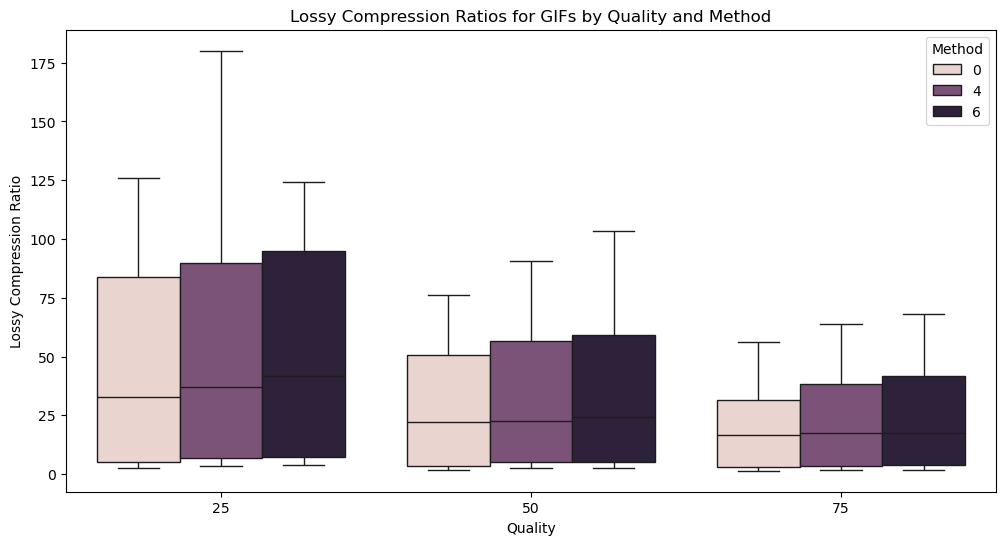

In [36]:
df_gif = df[df["File Type"] == "GIF"]
lossy_df_gif = lossy_df[lossy_df["File Type"] == "GIF"]

print("\nGIF Specific Analysis:")

# Lossless WebP for GIFs (show the actual values)
print("\nLossless WebP Compression Ratios for GIFs:")
print(df_gif[["Relative Path", "Lossless Compression Ratio"]])

# Lossy WebP for GIFs (show the actual values)
print("\nLossy WebP Compression Ratios for GIFs:")
print(lossy_df_gif[["Relative Path", "Quality", "Method", "Alpha Quality", "Lossy Compression Ratio"]])

# Visualize Lossy Compression Ratio Distribution for GIFs
plt.figure(figsize=(10, 6))
sns.histplot(lossy_df_gif["Lossy Compression Ratio"], bins=20)
plt.title("Distribution of Lossy Compression Ratios for GIFs")
plt.xlabel("Lossy Compression Ratio")
plt.ylabel("Frequency")
plt.show()

# Analyze Lossy Compression by Quality and Method for GIFs
plt.figure(figsize=(12, 6))
sns.boxplot(x="Quality", y="Lossy Compression Ratio", hue="Method", data=lossy_df_gif, showfliers=False)
plt.title("Lossy Compression Ratios for GIFs by Quality and Method")
plt.xlabel("Quality")
plt.ylabel("Lossy Compression Ratio")
plt.show()

In [37]:
df_gif

,Relative Path,Original Size,Scale,Has Alpha,File Type,ICC Profile,Lossless Size,Lossless No Alpha Size,lossy_q75_m0_a100,lossy_q75_m0_a80,...,lossy_q25_m0_a80,lossy_q25_m0_no_alpha,lossy_q25_m4_a100,lossy_q25_m4_a80,lossy_q25_m4_no_alpha,lossy_q25_m6_a100,lossy_q25_m6_a80,lossy_q25_m6_no_alpha,Lossless Compression Ratio,Lossless Alpha Diff
31,images/news/20170923-assaultmove.gif,29590,600x300,True,GIF,NaN,14896,14896.0,20442.0,20442.0,...,11110.0,11110,8244.0,8244.0,8244,7820.0,7820.0,7820,1.986439,0.0
59,images/news/20170421-td-hidpi.gif,82096,600x300,True,GIF,NaN,27274,27274.0,25934.0,25934.0,...,18244.0,18244,12008.0,12008.0,12008,11556.0,11556.0,11556,3.010046,0.0
66,images/news/20190209-opportunityfire.gif,677045,600x300,True,GIF,NaN,41040,41040.0,22708.0,22708.0,...,13202.0,13202,8888.0,8888.0,8888,8026.0,8026.0,8026,16.497198,0.0
69,images/news/20190606-directional-powers.gif,546926,590x350,True,GIF,NaN,20202,20202.0,17292.0,17292.0,...,5548.0,5548,4848.0,4848.0,4848,4398.0,4398.0,4398,27.072864,0.0
84,images/news/20190606-td-sidebar.gif,545519,1200x700,True,GIF,NaN,172172,172172.0,162752.0,162752.0,...,75830.0,75830,63922.0,63922.0,63922,59118.0,59118.0,59118,3.168454,0.0
127,images/news/2017-christmas.gif,186561,934x540,True,GIF,NaN,31276,31276.0,58842.0,58842.0,...,31560.0,31560,21816.0,21816.0,21816,19818.0,19818.0,19818,5.964989,0.0
130,images/news/20200303-rallypoint.gif,73176,600x300,True,GIF,NaN,20624,20624.0,39638.0,39638.0,...,19818.0,19818,17418.0,17418.0,17418,16494.0,16494.0,16494,3.548099,0.0
162,images/news/20190106-dog-attack.gif,1355367,600x300,True,GIF,NaN,94540,94540.0,32712.0,32712.0,...,16166.0,16166,15106.0,15106.0,15106,14266.0,14266.0,14266,14.336440,0.0
185,images/news/20151031-td.gif,2532196,600x300,True,GIF,NaN,49318,49318.0,7656.0,7656.0,...,2372.0,2372,1914.0,1914.0,1914,1788.0,1788.0,1788,51.344256,0.0
192,images/news/20170401-french-bonus.gif,843462,319x245,True,GIF,NaN,23574,23574.0,15038.0,15038.0,...,6704.0,6704,4684.0,4684.0,4684,3640.0,3640.0,3640,35.779333,0.0


In [40]:
df_gif[df_gif['Relative Path'] == 'images/news/20170923-assaultmove.gif']

,Relative Path,Original Size,Scale,Has Alpha,File Type,ICC Profile,Lossless Size,Lossless No Alpha Size,lossy_q75_m0_a100,lossy_q75_m0_a80,...,lossy_q25_m0_a80,lossy_q25_m0_no_alpha,lossy_q25_m4_a100,lossy_q25_m4_a80,lossy_q25_m4_no_alpha,lossy_q25_m6_a100,lossy_q25_m6_a80,lossy_q25_m6_no_alpha,Lossless Compression Ratio,Lossless Alpha Diff
31,images/news/20170923-assaultmove.gif,29590,600x300,True,GIF,NaN,14896,14896.0,20442.0,20442.0,...,11110.0,11110,8244.0,8244.0,8244,7820.0,7820.0,7820,1.986439,0.0


In [46]:
def extract_settings(col_name):
    if col_name.startswith("lossy_"):
        parts = col_name.split("_")
        quality = int(parts[1][1:])
        method = int(parts[2][1:])
        if "a" in parts[3]:
            alpha = int(parts[3][1:])
            no_alpha = False
        else:
            alpha = None
            no_alpha = True
        return quality, method, alpha, no_alpha
    else:
        return None

# Lossy Analysis
lossy_cols = [col for col in df.columns if col.startswith("lossy_")]
lossy_data = []

for index, row in df.iterrows():
    for col in lossy_cols:
        settings = extract_settings(col)
        if settings:
            quality, method, alpha, no_alpha = settings
            lossy_size = row[col]
            lossy_data.append({
                "File Type": row["File Type"],
                "Relative Path": row["Relative Path"],
                "Original Size": row["Original Size"],
                "Quality": quality,
                "Method": method,
                "Alpha Quality": alpha,
                "No Alpha": no_alpha,
                "Lossy Size": lossy_size
            })

In [ ]:
lossy_df[lossy_df['Relative Path'] == 'images/news/20170923-assaultmove.gif']

,File Type,Relative Path,Original Size,Quality,Method,Alpha Quality,No Alpha,Lossy Size,Lossy Compression Ratio
837,GIF,images/news/20170923-assaultmove.gif,29590,75,0,100.0,False,20442.0,1.447510
838,GIF,images/news/20170923-assaultmove.gif,29590,75,0,80.0,False,20442.0,1.447510
839,GIF,images/news/20170923-assaultmove.gif,29590,75,0,NaN,True,20442.0,1.447510
840,GIF,images/news/20170923-assaultmove.gif,29590,75,4,100.0,False,16112.0,1.836519
841,GIF,images/news/20170923-assaultmove.gif,29590,75,4,80.0,False,16112.0,1.836519
842,GIF,images/news/20170923-assaultmove.gif,29590,75,4,NaN,True,16112.0,1.836519
843,GIF,images/news/20170923-assaultmove.gif,29590,75,6,100.0,False,15362.0,1.926181
844,GIF,images/news/20170923-assaultmove.gif,29590,75,6,80.0,False,15362.0,1.926181
845,GIF,images/news/20170923-assaultmove.gif,29590,75,6,NaN,True,15362.0,1.926181
846,GIF,images/news/20170923-assaultmove.gif,29590,50,0,100.0,False,15042.0,1.967159
